# Question 9 — Image Sharpening
Apply image sharpening to a sapphire gemstone image using:
- Unsharp masking (Gaussian-based)
- Laplacian sharpening kernel

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_color(img_bgr, title=''):
    plt.figure(figsize=(7, 5))
    plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

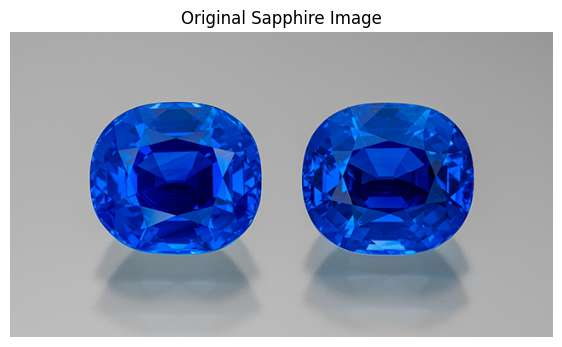

In [2]:
# Load sapphire image
img = cv.imread('images/sapphire.jpg')
assert img is not None
show_color(img, 'Original Sapphire Image')

## Method 1 — Unsharp Masking

Unsharp masking sharpens by adding a scaled version of the **high-frequency detail** back to the original:

$$g = f + \lambda \cdot (f - f_{blurred})$$

where $f_{blurred}$ is a Gaussian-smoothed version of the image and $\lambda$ controls the sharpening strength.

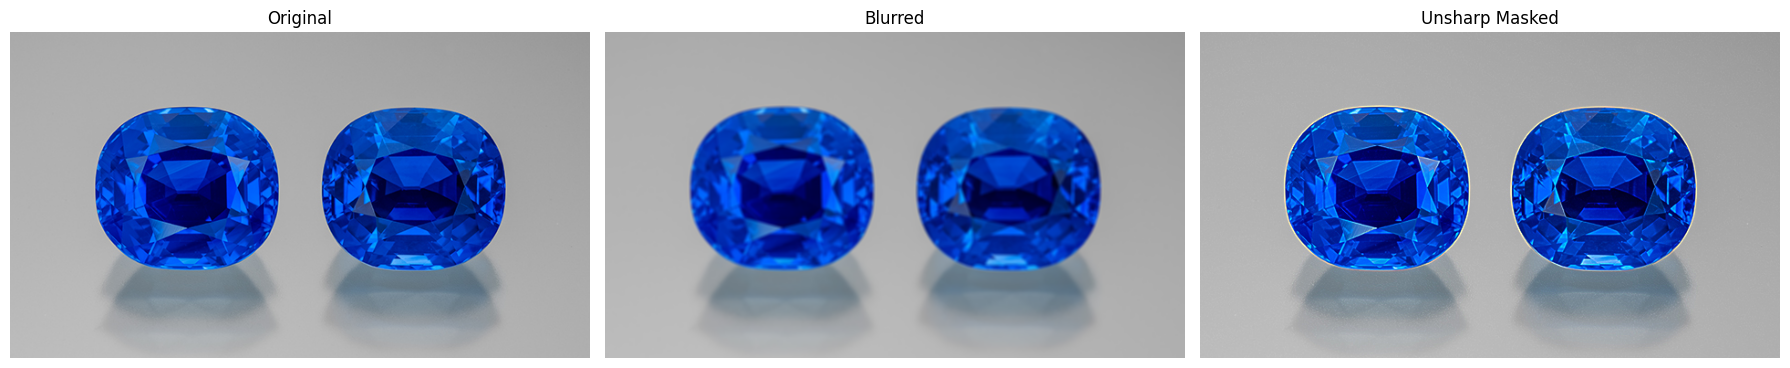

In [3]:
# Unsharp masking
blurred = cv.GaussianBlur(img, (5, 5), 2)
detail  = cv.subtract(img, blurred)           # high-frequency detail

# Add detail back — lambda=1.5 gives noticeable but natural sharpening
sharpened_unsharp = cv.addWeighted(img, 1.0, detail, 1.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, im, t in zip(axes,
    [img, blurred, sharpened_unsharp],
    ['Original', 'Blurred', 'Unsharp Masked']):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q9_unsharp_masking.png', dpi=150, bbox_inches='tight')
plt.show()

## Method 2 — Laplacian Sharpening Kernel

A simpler approach using a fixed sharpening kernel that combines the Laplacian (edge detector) with the identity:

$$K = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

The center value of 5 preserves the original pixel; the -1 weights subtract the local average, enhancing edges.

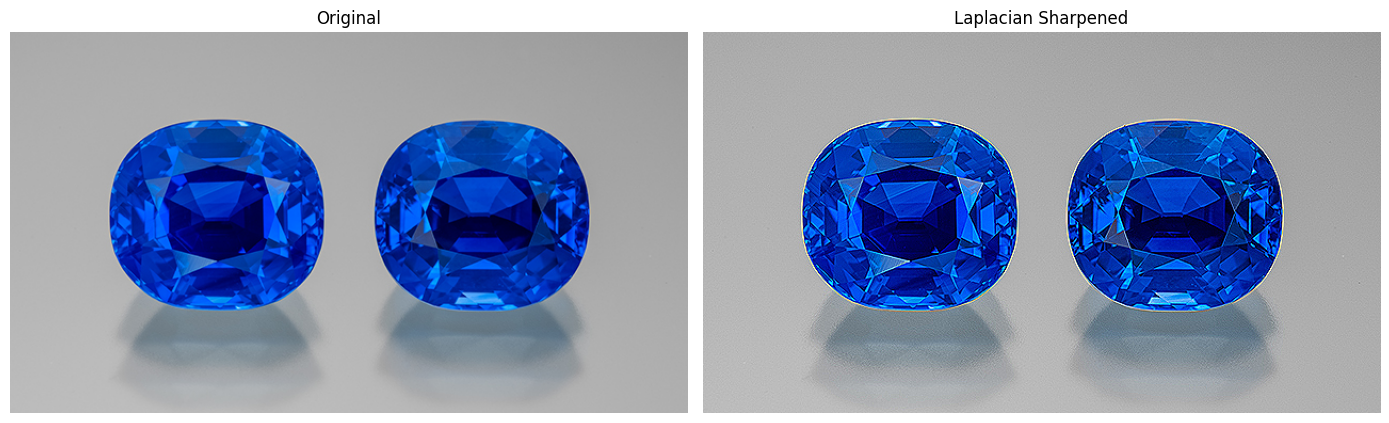

In [4]:
# Laplacian sharpening kernel
kernel = np.array([[ 0, -1,  0],
                   [-1,  5, -1],
                   [ 0, -1,  0]], dtype=np.float32)

sharpened_laplacian = cv.filter2D(img, -1, kernel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, im, t in zip(axes,
    [img, sharpened_laplacian],
    ['Original', 'Laplacian Sharpened']):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q9_laplacian_sharpening.png', dpi=150, bbox_inches='tight')
plt.show()

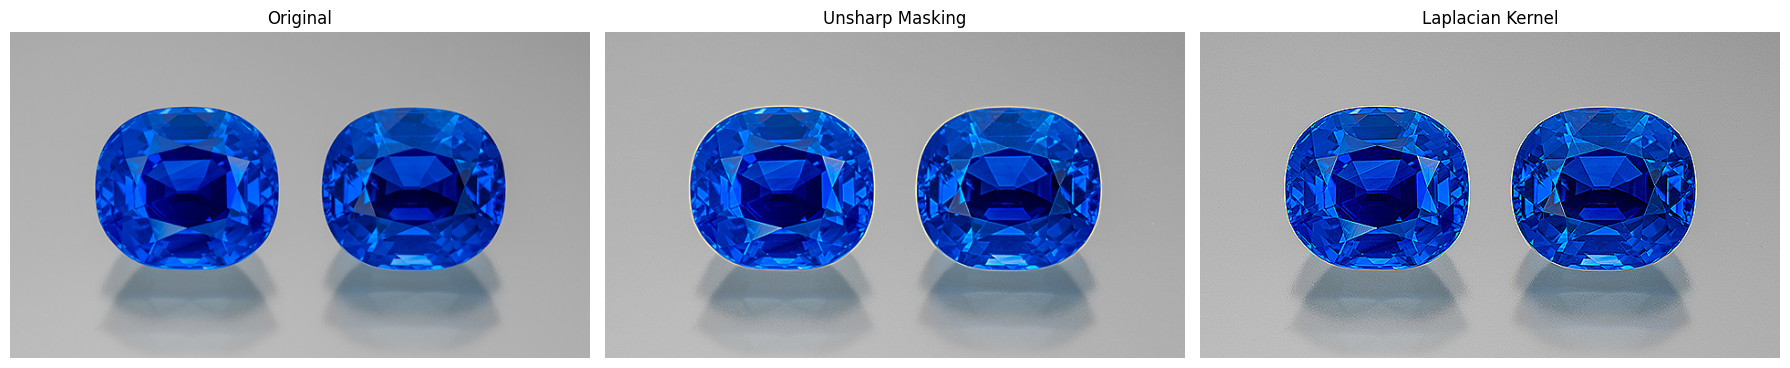

Observations:
  Unsharp masking: smooth, controlled sharpening — enhances facet edges
  and surface reflections without introducing artefacts.
  Laplacian kernel: stronger, faster sharpening — more aggressive on edges
  but can introduce ringing artefacts at very high contrast boundaries.


In [5]:
# Full summary — all results side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, im, t in zip(axes,
    [img, sharpened_unsharp, sharpened_laplacian],
    ['Original', 'Unsharp Masking', 'Laplacian Kernel']):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q9_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observations:')
print('  Unsharp masking: smooth, controlled sharpening — enhances facet edges')
print('  and surface reflections without introducing artefacts.')
print('  Laplacian kernel: stronger, faster sharpening — more aggressive on edges')
print('  but can introduce ringing artefacts at very high contrast boundaries.')